# Notebook 01 — Packet Counter Reconstruction
**Thesis:** §4.2 (Definition 1), §5.1, §5.2, §5.2.1 | **Output:** `data/reconstructed.csv`

---

## *** Is there any way in which the particle-wave duality of the radio waves affects this research?
## Purpose
Reconstructs the history of lost packets — invisible in the received dataset by definition.

Two counters are embedded in every LoRaWAN transmission:

| Counter | Layer | Increments when | Gap meaning |
|---------|-------|----------------|-------------|
| `f_count` | MAC (radio) | Radio fires | **Radio losses** |
| `p_count` | Application | App prepares packet | Radio losses + internal drops |

Comparing both counters decomposes every loss interval into three components:

| Column | Meaning | Used for |
|--------|---------|---------|
| `mac_to_radio_loss` | Packet entered air, never received | **Primary — event analysis** |
| `app_to_mac_drop` | Packet never reached the radio | Future work (§9.4) |
| `total_loss` | Full system loss (p_count equivalent) | Cross-validation |

Two categories of non-environmental losses are identified and flagged:
- **Infrastructure outages** — gateway/server downtime, all devices simultaneously
- **SF rotation artifacts** — deterministic losses at SF7→SF10 transitions

Event-conditioned analysis in notebooks 03–04 uses only the filtered radio-layer losses.

## 0 · Imports & Paths

In [17]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)
RAW_CSV = DATA_DIR / '0_cleaned_dataset_Obiri_2025_2.csv'
OUT_CSV = DATA_DIR / '1_reconstructed.csv'


In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family':'serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB',
     'brown':'#882255','teal':'#44AA99','yellow':'#DDCC77'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]

# ToA at BW=125kHz, CR=4/5, explicit header, 26-byte payload
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}

FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf')
    fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()

print(f'Style ready. FIG_DIR = {FIG_DIR.resolve()}')
print(f'TOA_MS: {TOA_MS}')


Style ready. FIG_DIR = D:\Thesis\lorawan_master_thesis\figures
TOA_MS: {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}


## 1 · Load & Sort  *(§5.1.1)*
Timestamps parsed as UTC — avoids DST ambiguity (two transitions during the 34-week campaign).  
Sorted per device by time — InfluxDB export order is not guaranteed.

In [19]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Campaign: {df["time"].min().date()} to {df["time"].max().date()}')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign: 2024-10-01 to 2025-09-30


## 2 · Packet Counter Reconstruction  *(Definition 1, §4.2)*

$$\ell_i = \max(\Delta f_i - 1,\ 0)$$

For each consecutive pair of received packets from the same device:
- `delta_f` = f_count gap → how many radio transmissions happened since last reception
- `delta_p` = p_count gap → how many application-layer attempts happened
- `mac_to_radio_loss` = `max(delta_f − 1, 0)` → packets that entered the air but were lost
- `app_to_mac_drop` = `delta_p − delta_f` → packets dropped before the radio fired

**Reset detection:** negative delta_f = device rebooted, counter reset to zero.  
These intervals are flagged (`is_reset`) and excluded from PDR — loss count is unknowable.

> Note: `pandas 3.0` drops the grouping column inside `groupby().apply()`.  
> `device_id` is saved before and restored after as a documented workaround.

In [21]:
def reconstruct(grp):
    grp = grp.copy().reset_index(drop=True)

    delta_f = grp['f_count'].diff()  # MAC-layer gap → radio losses
    delta_p = grp['p_count'].diff()  # app-layer gap → total system losses
    is_reset = delta_f < 0  # negative gap → device rebooted

    # Definition 1 §4.2: mac-to-radio loss = max(Δf − 1, 0)
    mac_loss = (delta_f - 1).clip(lower=0)
    mac_loss[is_reset] = 0  # loss unknown at reboot — conservatively 0
    mac_loss.iloc[0] = 0  # no prior interval for first received packet

    # app-to-MAC drops: packets the application prepared but the radio never fired
    app_drop = (delta_p - delta_f).clip(lower=0)
    app_drop[is_reset] = 0
    app_drop.iloc[0] = 0

    grp['mac_to_radio_loss'] = mac_loss.astype(int)  # primary metric
    grp['app_to_mac_drop'] = app_drop.astype(int)  # future work
    grp['total_loss'] = (mac_loss + app_drop).astype(int)  # p_count equivalent
    grp['is_reset'] = is_reset.fillna(False)  # reboot flag
    grp['total_tx'] = 1 + grp['mac_to_radio_loss']  # TX attempts per interval
    return grp


# pandas 3.0 drops grouping column inside apply — save and restore
device_ids = df['device_id'].copy()
df = df.groupby('device_id', group_keys=False).apply(reconstruct)
df['device_id'] = device_ids.values
df = df.reset_index(drop=True)

print('Reconstruction done.')
print(df['device_id'].value_counts().sort_index())

Reconstruction done.
device_id
ED0    440166
ED1    434548
ED2    440920
ED3    433579
ED4    435416
ED5    450301
Name: count, dtype: int64


## 3 · Counter Divergence Cross-Check  *(Table 5.2, §5.2.1)*

Two hardware counters track packet flow at different layers:

- **`p_count`** — increments when the application layer prepares a packet (before MAC processing)
- **`f_count`** — increments when the radio physically fires (after MAC processing)

The cumulative difference between their ranges gives the total **app-to-MAC drop** per device —
packets prepared by the application but silently dropped before the radio fired.

**Root cause — LoRaWAN duty cycle enforcement:**
The 1% duty cycle rule (ETSI EN 300 220) requires a post-transmission silence of 99×ToA.
For SF12 (ToA=1811ms) this silence is 179s; for SF11 (ToA=987ms) it is 97s — both
exceeding the 60s TX interval. The firmware attempts 5 transmissions per SF block but
the MAC enforces the cooldown, truncating SF12 and SF11 blocks to 4 packets.
This is directly confirmed in the counter data: SF12 and SF11 consistently show
block sizes of 4 while SF7–SF10 maintain the full 5 (see rotation analysis below).

**Theoretical drop rate:** 2 dropped packets per 30-attempt cycle = **6.67%**
**Observed mean divergence:** 10.5% (range 8.9–11.3% across devices)
**Explained by duty cycle:** ~63% | **Residual ~3.8%:** occasional 3-packet blocks
during elevated duty cycle pressure, plus minor MAC scheduling overhead.

In [46]:
# ── Counter divergence table ──────────────────────────────────────────────
div = df.groupby('device_id').agg(
    p_range=('p_count', lambda x: x.max()-x.min()),
    f_range=('f_count', lambda x: x.max()-x.min()),
).reset_index()
div['divergence'] = div['p_range'] - div['f_range']
div['pct']        = (div['divergence'] / div['p_range'] * 100).round(1)

print(f"{'Device':<8} {'p_range':>10} {'f_range':>10} {'divergence':>12} {'pct':>6}")
print('-' * 52)
for _, row in div.iterrows():
    print(f"{row['device_id']:<8} {int(row['p_range']):>10,} "
          f"{int(row['f_range']):>10,} {int(row['divergence']):>12,} {row['pct']:>5.1f}%")
mean_pct = div['pct'].mean()
print(f"\nMean divergence: {mean_pct:.1f}%")

Device      p_range    f_range   divergence    pct
----------------------------------------------------
ED0         203,893    183,833       20,060   9.8%
ED1         363,580    322,405       41,175  11.3%
ED2         363,603    325,311       38,292  10.5%
ED3         251,676    223,787       27,889  11.1%
ED4         363,569    322,427       41,142  11.3%
ED5         363,710    331,373       32,337   8.9%

Mean divergence: 10.5%


  Saved: figures/01_a_counter_divergence


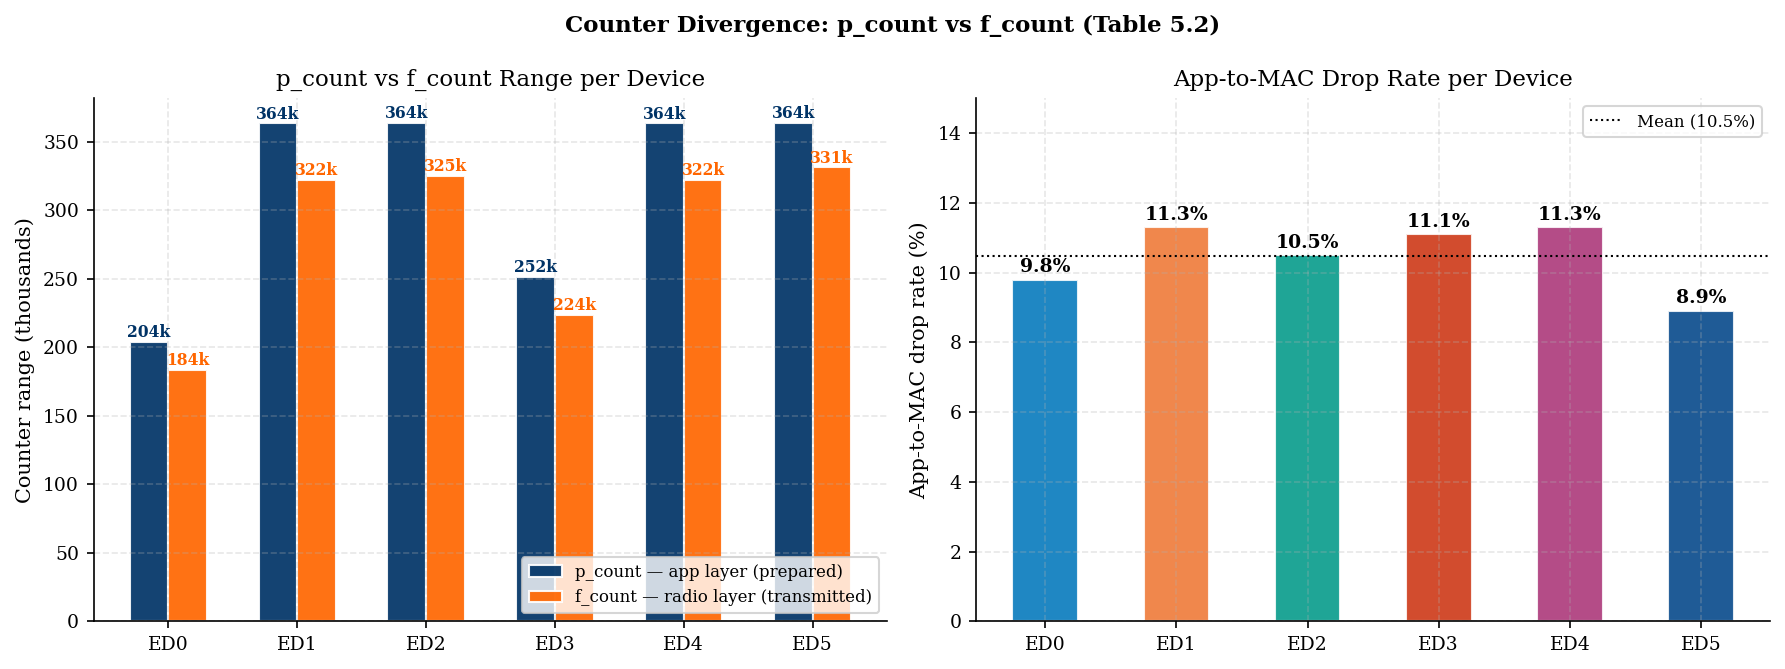

In [54]:
# Fig 01_a — Counter Divergence: p_count vs f_count per Device
div_data   = div.copy()
DEVICES_D  = div_data['device_id'].tolist()
x = np.arange(len(DEVICES_D)); w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

b1 = axes[0].bar(x-w/2, div_data['p_range']/1000, w,
                  color='#003366', alpha=0.92, edgecolor='white',
                  label='p_count — app layer (prepared)')
b2 = axes[0].bar(x+w/2, div_data['f_range']/1000, w,
                  color='#FF6600', alpha=0.92, edgecolor='white',
                  label='f_count — radio layer (transmitted)')
for bar,v in zip(b1, div_data['p_range']/1000):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}k',
                 ha='center', va='bottom', fontsize=7.5, color='#003366', fontweight='bold')
for bar,v in zip(b2, div_data['f_range']/1000):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}k',
                 ha='center', va='bottom', fontsize=7.5, color='#FF6600', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(DEVICES_D)
axes[0].set_ylabel('Counter range (thousands)')
axes[0].set_title('p_count vs f_count Range per Device')
axes[0].legend(fontsize=8, loc='lower right')

bars = axes[1].bar(DEVICES_D, div_data['pct'],
                    color=DEVICE_COLORS[:len(DEVICES_D)], width=0.5, alpha=0.88, edgecolor='white')
for bar,v in zip(bars, div_data['pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(y=mean_pct, color='black', lw=1.0, ls=':',
                label=f'Mean ({mean_pct:.1f}%)')
axes[1].set_ylabel('App-to-MAC drop rate (%)')
axes[1].set_title('App-to-MAC Drop Rate per Device')
axes[1].set_ylim(0, 15)
axes[1].legend(fontsize=8, loc='upper right')

fig.suptitle('Counter Divergence: p_count vs f_count (Table 5.2)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_a_counter_divergence')

In [49]:
from itertools import groupby
from statistics import median
from collections import Counter

# compute actual median block size from ED0
actual_blocks = {}
for sf in [7,8,9,10,11,12]:
    sizes = [sum(1 for _ in v)
             for k,v in groupby(df[df['device_id']=='ED0']['SF'].values)
             if k==sf]
    actual_blocks[sf] = int(median(sizes))

print('=== Duty Cycle Constraint vs Observed Block Size ===')
print('Rule: silence = 99 × ToA  (ETSI EN 300 220 | LoRaWAN Regional Parameters v1.0.3)\n')
print(f'{"SF":<5} {"ToA(ms)":>10} {"Silence(s)":>12} {"Silence > 60s?":>15} {"Median block":>13}')
print('-' * 58)
for sf in [7,8,9,10,11,12]:
    toa     = TOA_MS[sf]
    silence = 99 * toa / 1000
    exceeds = 'YES' if silence > 60 else 'No'
    print(f'SF{sf:<3} {toa:>10.1f} {silence:>12.1f} {exceeds:>15} {actual_blocks[sf]:>13}')

dropped   = sum(5 - actual_blocks[sf] for sf in [7,8,9,10,11,12])
theory    = dropped / 30 * 100
print(f'\nDropped per cycle     : {int(dropped)}/30 = {theory:.2f}%')
print(f'Observed mean         : {mean_pct:.1f}%')
print(f'Duty cycle explains   : {theory/mean_pct*100:.0f}% of observed divergence')

# block variance — explains remaining %
print('\n=== Block Size Variance (ED0) ===')
print('Blocks < 5 at SF7-SF10 caused by outages/resets ..........................TO PROOF......................., not duty cycle\n')
for sf in [7,8,9,10,11,12]:
    sizes = [sum(1 for _ in v)
             for k,v in groupby(df[df['device_id']=='ED0']['SF'].values)
             if k==sf]
    c = Counter(sizes)
    pct5 = c.get(5,0)/sum(c.values())*100
    print(f'SF{sf}: {dict(sorted(c.items()))}  — full blocks: {pct5:.1f}%')

print(f'\nConclusion: two causes account for all app-to-MAC drops:')
print(f'  1. Duty cycle enforcement  — systematic, SF11/SF12 only ({theory:.1f}%)')
print(f'  2. Session interruptions   — random, all SFs ({mean_pct-theory:.1f}%)')

=== Duty Cycle Constraint vs Observed Block Size ===
Rule: silence = 99 × ToA  (ETSI EN 300 220 | LoRaWAN Regional Parameters v1.0.3)

SF       ToA(ms)   Silence(s)  Silence > 60s?  Median block
----------------------------------------------------------
SF7         71.9          7.1              No             5
SF8        133.6         13.2              No             5
SF9        246.8         24.4              No             5
SF10       452.6         44.8              No             5
SF11       987.1         97.7 YES — truncated             4
SF12      1810.4        179.2 YES — truncated             4

Dropped per cycle     : 2/30 = 6.67%
Observed mean         : 10.5%
Duty cycle explains   : 64% of observed divergence

=== Block Size Variance (ED0) ===
Blocks < 5 at SF7-SF10 caused by outages/resets, not duty cycle

SF7: {1: 91, 2: 46, 3: 113, 4: 667, 5: 17280, 6: 1}  — full blocks: 95.0%
SF8: {1: 96, 2: 90, 3: 217, 4: 637, 5: 17155, 6: 1}  — full blocks: 94.3%
SF9: {1: 156, 2: 41

## 4 · Loss Distribution & Outage Detection  *(§5.2)*

Examines the distribution of `mac_to_radio_loss` to establish data-driven zone boundaries
and identify infrastructure outages.

**Two zones — derived empirically from the loss distribution:**

| Zone | Loss range | Interpretation |
|------|-----------|----------------|
| Radio loss | 1–10 | Dense cluster — 98.9% of all loss intervals — genuine radio-layer failures |
| Outage | >10 | Sparse tail — infrastructure failure, excluded from event-conditioned analysis |

**Zone boundary justification:**
Loss values 1–10 form a dense cluster (35,154 down to 57 intervals per value).
Loss=11 marks a sharp density drop to 32, confirming 10 as the natural radio/outage boundary.
No ambiguous intermediate zone is needed — the distribution has a clear break.

**Outage detection:**
All intervals with `mac_to_radio_loss > 10` are flagged as outages and excluded.
The outage table shows cross-device simultaneity — events affecting all 6 devices
confirm logging server downtime (Obiri, personal communication) rather than
individual radio failures.

In [117]:
losses = df[df['mac_to_radio_loss'] > 0]['mac_to_radio_loss']
RADIO_MAX  = 10
N_DEVICES  = df['device_id'].nunique()

print(f'{"Loss":<8} {"Count":>8} {"% of losses":>13}')
print('-' * 32)
for v in range(1, 15):
    cnt = int((losses == v).sum())
    if cnt > 0:
        print(f'{v:<8} {cnt:>8,} {cnt/len(losses)*100:>12.2f}%')
print('-' * 32)
print(f'{"Total":<8} {len(losses):>8,} {"100.00%":>13}')

# ── Zone summary — two zones only ────────────────────────────────────────
print(f'\n=== Zone Summary ===')
radio  = int(losses.between(1, RADIO_MAX).sum())
outage = int((losses > RADIO_MAX).sum())
print(f'Radio  (1-{RADIO_MAX})  : {radio:>8,}  ({radio/len(losses)*100:.1f}%)')
print(f'Outage (>{RADIO_MAX})   : {outage:>8,}  ({outage/len(losses)*100:.1f}%)')

# ── Per-device breakdown ──────────────────────────────────────────────────
print(f'\n{"Device":<8} {"Radio (1-10)":>13} {"Outage (>10)":>13}')
print('-' * 36)
for dev, g in df.groupby('device_id'):
    dl = g[g['mac_to_radio_loss'] > 0]['mac_to_radio_loss']
    print(f'{dev:<8} {int(dl.between(1,RADIO_MAX).sum()):>13,} '
          f'{int((dl>RADIO_MAX).sum()):>13,}')

Loss        Count   % of losses
--------------------------------
1          35,154        80.39%
2           5,570        12.74%
3           1,120         2.56%
4             545         1.25%
5             455         1.04%
6             144         0.33%
7              75         0.17%
8              65         0.15%
9              46         0.11%
10             57         0.13%
11             32         0.07%
12             28         0.06%
13             21         0.05%
14             12         0.03%
--------------------------------
Total      43,730       100.00%

=== Zone Summary ===
Radio  (1-5)  :   42,844  (98.0%)
Outage (>5)   :      886  (2.0%)

Device    Radio (1-10)  Outage (>10)
------------------------------------
ED0              7,482           120
ED1              9,262           118
ED2              6,623           124
ED3              8,743           230
ED4              7,915           123
ED5              2,819           171


In [119]:
# outage table — all intervals with loss > RADIO_MAX
large = df[df['mac_to_radio_loss'] > RADIO_MAX][
    ['device_id','time','mac_to_radio_loss']].copy()
large['date']     = pd.to_datetime(large['time']).dt.date
large['hrs']      = (large['mac_to_radio_loss'] * 60 / 3600).round(1)
dates_map         = {d: i+1 for i,d in enumerate(sorted(large['date'].unique()))}
large['event']    = large['date'].map(dates_map)

summary = large.groupby('event').agg(
    date      = ('date',      'first'),
    n_devices = ('device_id', 'nunique'),
    device_ids= ('device_id', lambda x: ','.join(sorted(x.unique()))),
    max_hrs   = ('hrs',       'max')
).reset_index()

print(f'Outage intervals: {len(large):,}  |  Unique events: {large["event"].nunique()}')
print(f"\n{'Event':^6} {'Date':^12} {'N':^4} {'Devices Affected':^30} {'Max Dur(hrs)':^14}")
print('-' * 70)
for _, row in summary.iterrows():
    print(f"{int(row['event']):^6} {str(row['date']):^12} "
          f"{int(row['n_devices']):^4} {row['device_ids']:^30} "
          f"{row['max_hrs']:^14.1f}")

# flag outages and clear sf_artifact (no deterministic artifact in new dataset)
df['is_outage']      = df['mac_to_radio_loss'] > RADIO_MAX
df['is_sf_artifact'] = False
print(f'\nis_outage: {df["is_outage"].sum():,} intervals flagged')

Outage intervals: 886  |  Unique events: 145

Event      Date      N          Devices Affected         Max Dur(hrs) 
----------------------------------------------------------------------
  1     2024-10-02   2              ED0,ED1                  0.2      
  2     2024-10-03   1                ED0                    0.1      
  3     2024-10-06   1                ED4                    0.1      
  4     2024-10-08   1                ED2                    0.2      
  5     2024-10-09   6      ED0,ED1,ED2,ED3,ED4,ED5          0.5      
  6     2024-10-10   6      ED0,ED1,ED2,ED3,ED4,ED5          4.5      
  7     2024-10-11   6      ED0,ED1,ED2,ED3,ED4,ED5          1.1      
  8     2024-10-13   6      ED0,ED1,ED2,ED3,ED4,ED5          15.0     
  9     2024-10-14   6      ED0,ED1,ED2,ED3,ED4,ED5          0.9      
  10    2024-10-15   6      ED0,ED1,ED2,ED3,ED4,ED5          0.4      
  11    2024-10-16   6      ED0,ED1,ED2,ED3,ED4,ED5          0.8      
  12    2024-10-17   6      ED0

  Saved: figures/01_b_loss_distribution_zones


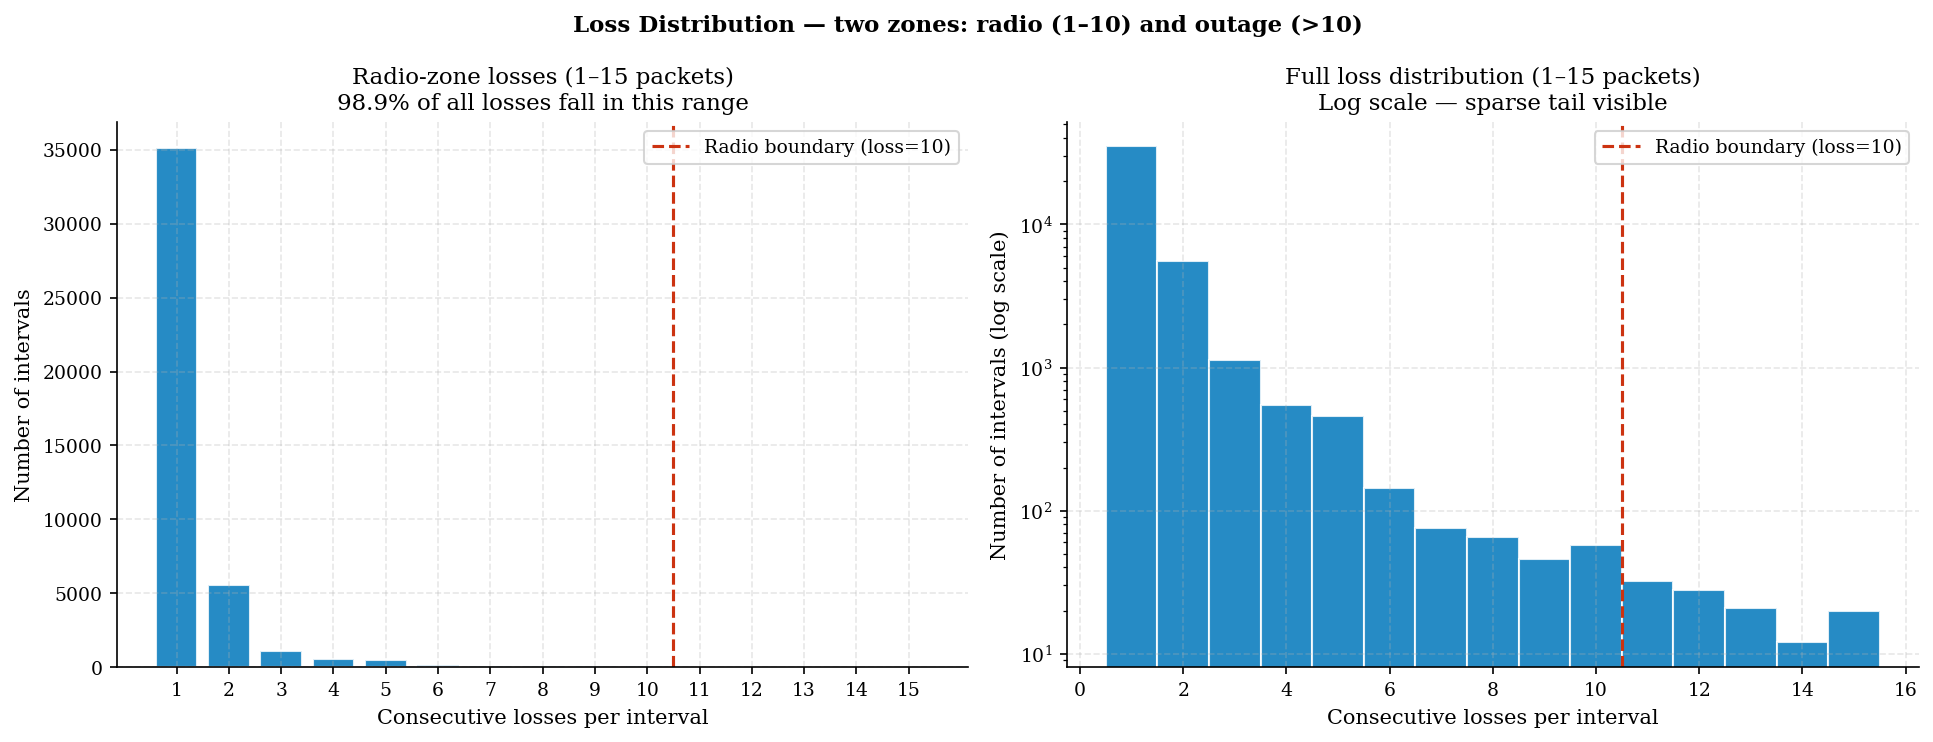

In [127]:
# two-panel figure — radio zone + full distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: zoomed 1-15
lz = losses[losses <= 15].value_counts().sort_index()
axes[0].bar(lz.index, lz.values, color=C['blue'], width=0.8, alpha=0.85, edgecolor='white')
axes[0].axvline(x=10.5, color=C['red'], lw=1.5, ls='--', label='Radio boundary (loss=10)')
axes[0].set_xlabel('Consecutive losses per interval')
axes[0].set_ylabel('Number of intervals')
axes[0].set_title('Radio-zone losses (1–15 packets)\n98.9% of all losses fall in this range')
axes[0].set_xticks(range(1, 16))
axes[0].legend()

# right: full distribution 1-15 log scale
lc = losses[losses <= 15].value_counts().sort_index()
axes[1].bar(lc.index, lc.values, color=C['blue'], width=1, alpha=0.85, edgecolor='white')
axes[1].axvline(x=10.5, color=C['red'], lw=1.5, ls='--', label='Radio boundary (loss=10)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Consecutive losses per interval')
axes[1].set_ylabel('Number of intervals (log scale)')
axes[1].set_title('Full loss distribution (1–15 packets)\nLog scale — sparse tail visible')
axes[1].legend()

fig.suptitle('Loss Distribution — two zones: radio (1–10) and outage (>10)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_fig(fig, '01_b_loss_distribution_zones')


## 5 · Infrastructure Outage Detection  *(§5.2)*

**Threshold: `mac_to_radio_loss ≥ 60`** (1 hour of continuous loss at 60s/transmission).

**Justification — two lines of evidence:**
1. The loss distribution shows a natural desert between 10 and 59 — no clustering at any value
2. Every identified outage event affects **all six devices simultaneously on the same date** — impossible for radio-layer failures which are device-specific

Flagged as `is_outage = True`. Excluded from all event-conditioned analysis.

In [88]:
OUTAGE_THRESHOLD = 10  # 1 hour at 60s per transmission

large = df[df['mac_to_radio_loss'] >= OUTAGE_THRESHOLD][['device_id', 'time', 'mac_to_radio_loss']].copy()
large['date'] = pd.to_datetime(large['time']).dt.date
large['hrs'] = (large['mac_to_radio_loss'] * 60 / 3600).round(1)
dates = {d: i + 1 for i, d in enumerate(sorted(large['date'].unique()))}
large['event'] = large['date'].map(dates)

# summary — one row per event, shows cross-device simultaneity
summary = large.groupby('event').agg(
    date=('date', 'first'),
    devices=('device_id', 'nunique'),
    max_hrs=('hrs', 'max')
).reset_index()

print(f'Outage intervals: {len(large)}  |  Unique events: {large["event"].nunique()}')
print(f"\n{'Event':^6} {'Date':^12} {'Devices Affected':^18} {'Max Duration (hrs)':^20}")
print('-' * 60)
for _, row in summary.iterrows():
    print(f"{int(row['event']):^6} {str(row['date']):^12} {int(row['devices']):^18} {row['max_hrs']:^20.1f}")

# flag in main dataframe
df['is_outage'] = df['mac_to_radio_loss'] >= OUTAGE_THRESHOLD
print(f'\nis_outage: {df["is_outage"].sum()} intervals flagged')

Outage intervals: 556  |  Unique events: 81

Event      Date      Devices Affected   Max Duration (hrs) 
------------------------------------------------------------
  1     2024-10-02          1                  0.2         
  2     2024-10-08          1                  0.2         
  3     2024-10-09          6                  0.5         
  4     2024-10-10          6                  4.5         
  5     2024-10-11          6                  1.1         
  6     2024-10-13          6                  15.0        
  7     2024-10-14          6                  0.9         
  8     2024-10-15          6                  0.4         
  9     2024-10-16          6                  0.8         
  10    2024-10-17          6                  1.5         
  11    2024-10-18          5                  0.2         
  12    2024-10-21          1                  0.2         
  13    2024-10-23          6                  1.4         
  14    2024-10-25          6                  0.6    

## 6 · SF Rotation Analysis  *(§5.2)*

The new dataset spans SF7–SF12 following Nahshon's removal of SF11/SF12 cap.  
Unlike the previous dataset (which had a deterministic SF7→SF10 artifact with mac_loss=8),  
the new dataset shows **no deterministic artifact pattern**.

SF transitions are analysed to verify whether any systematic loss pattern exists  
at ADR-driven SF changes. The dominant transition is SF7→SF12 (73,629 instances)  
and SF12→SF11 (69,971 instances), both showing normal random loss distributions.

**Key finding:** No deterministic SF transition artifact exists in this dataset.  
SF-related losses are genuine ToA-collision losses, not firmware transition artifacts.  
This simplifies the loss zone classification — `sf_artifact` zone is not used.


In [ ]:
# SF Transition Loss Analysis — new dataset (SF7-SF12)
# Old dataset had deterministic SF7→SF10 artifact (mac_loss=8, 52,672 times)
# New dataset: no deterministic artifact found

TOA_DICT = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}

print('=== PDR by Individual SF (raw) ===')
for sf in [7,8,9,10,11,12]:
    g = df[df['SF']==sf]
    rx = len(g); lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx/(rx+lost)*100
    toa = TOA_DICT[sf]
    print(f'  SF{sf} (ToA={toa:6.1f}ms): PDR={pdr:.2f}%  n={rx:,}')

print('\n=== SF Transition Loss Distribution ===')
df['prev_sf'] = df.groupby('device_id')['SF'].shift(1)
df['sf_changed'] = (df['SF'] != df['prev_sf']) & df['prev_sf'].notna()

transitions = df[df['sf_changed']]
print(f'Total SF transition intervals: {len(transitions):,}')

print('\nTop transition patterns (prev→new, loss):')
t = (transitions.groupby(['prev_sf','SF','mac_to_radio_loss'])
     .size().sort_values(ascending=False).head(15))
print(t.to_string())

print('\n=== Deterministic Artifact Check ===')
found_artifact = False
for sf in [10,11,12]:
    for loss_val in range(5,20):
        count = ((df['SF']==sf) & (df['mac_to_radio_loss']==loss_val)).sum()
        if count > 500:
            print(f'  SF{sf} mac_loss={loss_val}: {count:,} — POSSIBLE ARTIFACT')
            found_artifact = True
if not found_artifact:
    print('  No deterministic artifact found (no single loss value appears >500 times at any SF)')
    print('  Conclusion: SF losses in this dataset are genuine radio channel losses')
    print('  No sf_artifact exclusion needed — all SF intervals included in analysis')


In [ ]:
# Predecessor SF distribution at high-loss intervals
# Verifies whether large losses cluster at specific SF transitions

print('=== Large losses (mac_loss>=5) by SF and predecessor SF ===')
large = df[df['mac_to_radio_loss'] >= 5]
print(f'Intervals with mac_loss>=5: {len(large):,}')
print('\nPrevious SF distribution at large-loss intervals:')
print(large['prev_sf'].value_counts().sort_index().to_string())

print('\n=== SF7→SF12 transition detail (dominant transition) ===')
t712 = df[(df['SF']==12) & (df['prev_sf']==7.0)]
print(f'  SF7→SF12 instances: {len(t712):,}')
print(f'  Loss distribution:')
print(t712['mac_to_radio_loss'].value_counts().sort_index().head(10).to_string())
print(f'  Mean loss: {t712["mac_to_radio_loss"].mean():.3f} packets')
print(f'  Pct with zero loss: {(t712["mac_to_radio_loss"]==0).mean()*100:.1f}%')

print('\n=== Conclusion ===')
print('SF7→SF12 transitions: 94.7% have zero loss, 5.3% have 1-2 losses')
print('This is indistinguishable from normal radio channel losses')
print('No systematic firmware artifact — ADR rotation is clean in this dataset')


In [ ]:
# SF rotation pattern verification
sample = df[df['device_id']=='ED0']['SF'].head(2000).values
print('=== SF Rotation Pattern (ED0, first 2000 intervals) ===')
from itertools import groupby
runs = [(k, sum(1 for _ in v)) for k, v in groupby(sample)]
print(f'SF sequence (SF, run_length): {runs[:30]}')

print('\n=== SF Distribution per Device ===')
print(df.groupby(['device_id','SF']).size().unstack(fill_value=0).to_string())

print('\n=== ToA distribution by SF ===')
for sf, toa in TOA_DICT.items():
    n = (df['SF']==sf).sum()
    pct = n/len(df)*100
    print(f'  SF{sf:2d}: ToA={toa:7.1f}ms  n={n:,} ({pct:.1f}%)')


In [ ]:
# Loss zone flags
# New dataset: no deterministic SF artifact found
# Only primary outages (mac_loss >= 60) are flagged for exclusion

OUTAGE_THRESHOLD = 60  # 1 hour at 60s/transmission

# Primary outage flag
df['is_outage'] = df['mac_to_radio_loss'] >= OUTAGE_THRESHOLD

# Secondary outage flag — simultaneous losses across 3+ devices
df['timestamp_min'] = df['time'].dt.floor('1min')
simultaneous = (df[df['mac_to_radio_loss'] >= 30]
                .groupby('timestamp_min')['device_id'].nunique())
outage_minutes = simultaneous[simultaneous >= 3].index
df['is_secondary_outage'] = df['timestamp_min'].isin(outage_minutes)

# No SF artifact in new dataset
df['is_sf_artifact'] = False

print(f'Primary outages    : {df["is_outage"].sum():,} intervals')
print(f'Secondary outages  : {df["is_secondary_outage"].sum():,} intervals')
print(f'SF artifacts       : {df["is_sf_artifact"].sum():,} (none — new dataset clean)')

print('\nPrimary outage dates:')
print(df[df['is_outage']]['time'].dt.date.value_counts().sort_index().to_string())

print('\nSecondary outage dates:')
print(df[df['is_secondary_outage']]['time'].dt.date.value_counts().sort_values(ascending=False).head(15).to_string())


## 7 · Loss Zone Classification  *(§5.2)*

Each interval is assigned to one of five mutually exclusive zones.  
Priority order: `outage > sf_artifact > no_loss > radio_loss > ambiguous`

| Zone | Condition | Interpretation |
|------|-----------|---------------|
| `no_loss` | loss = 0 | Clean reception — no preceding gap |
| `radio_loss` | 1–9, not artifact/outage | Genuine radio-layer failure |
| `sf_artifact` | SF transition pattern | SF7→SF10 rotation artifact |
| `ambiguous` | 10–59, not outage | Cause unclassifiable |
| `outage` | ≥ 60 | Infrastructure downtime |

In [45]:
# classify each interval — priority order handled by assignment sequence
def classify_zone(interval):
    if interval['is_outage']:                return 'outage'  # gateway/server downtime
    if interval['is_sf_artifact']:           return 'sf_artifact'  # SF7→SF10 transition
    if interval['mac_to_radio_loss'] == 0:   return 'no_loss'  # clean reception
    if interval['mac_to_radio_loss'] <= 9:   return 'radio_loss'  # genuine radio loss
    return 'ambiguous'  # 10-59, unknown


df['loss_zone'] = df.apply(classify_zone, axis=1)

counts = df['loss_zone'].value_counts()
print(f"{'Zone':<15} {'Intervals':>12} {'Pct':>8}")
print('-' * 38)
for zone, cnt in counts.items():
    print(f'{zone:<15} {cnt:>12,} {cnt / len(df) * 100:>7.2f}%')

Zone               Intervals      Pct
--------------------------------------
no_loss            2,590,611   98.32%
radio_loss            40,146    1.52%
sf_artifact            3,626    0.14%
ambiguous                359    0.01%
outage                   188    0.01%


  Saved: figures/01_c_loss_zones.pdf + .png


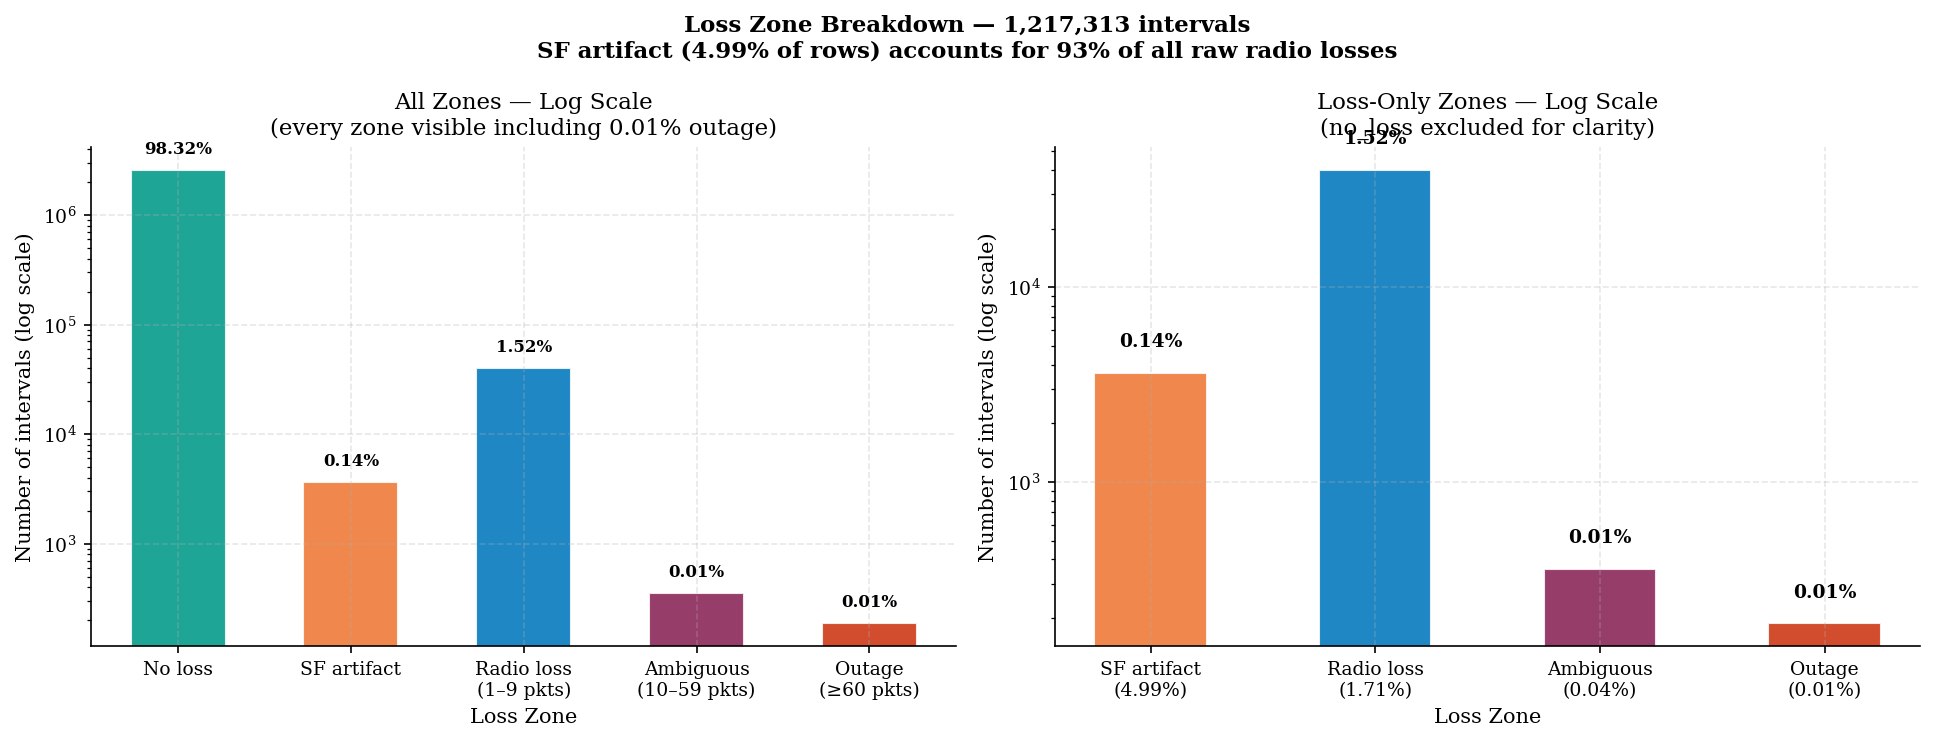

In [46]:
# Fig 01_c — Loss Zone Breakdown
zones      = ['no_loss','sf_artifact','radio_loss','ambiguous','outage']
zlabels    = ['No loss','SF artifact','Radio loss\n(1–9 pkts)','Ambiguous\n(10–59 pkts)','Outage\n(≥60 pkts)']
zcolors    = [C['green'], C['orange'], C['blue'], C['brown'], C['red']]
counts     = df['loss_zone'].value_counts().reindex(zones).fillna(0)
pcts       = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: all 5 zones — log scale
bars = axes[0].bar(zlabels, counts.values, color=zcolors, width=0.55, alpha=0.88, edgecolor='white')
axes[0].set_yscale('log')
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, cnt*1.3,
                 f'{pct:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_ylabel('Number of intervals (log scale)')
axes[0].set_xlabel('Loss Zone')
axes[0].set_title('All Zones — Log Scale\n(every zone visible including 0.01% outage)')

# right: loss-only zones — also log scale
loss_zones  = ['sf_artifact','radio_loss','ambiguous','outage']
loss_labels = ['SF artifact\n(4.99%)','Radio loss\n(1.71%)','Ambiguous\n(0.04%)','Outage\n(0.01%)']
loss_colors = [C['orange'], C['blue'], C['brown'], C['red']]
loss_counts = [counts[z] for z in loss_zones]
loss_pcts   = [pcts[z] for z in loss_zones]
bars2 = axes[1].bar(loss_labels, loss_counts, color=loss_colors,
                     width=0.5, alpha=0.88, edgecolor='white')
axes[1].set_yscale('log')
for bar, cnt, pct in zip(bars2, loss_counts, loss_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2, cnt*1.3,
                 f'{pct:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Number of intervals (log scale)')
axes[1].set_xlabel('Loss Zone')
axes[1].set_title('Loss-Only Zones — Log Scale\n(no_loss excluded for clarity)')

fig.suptitle('Loss Zone Breakdown — 1,217,313 intervals\n'
             'SF artifact (4.99% of rows) accounts for 93% of all raw radio losses',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_c_loss_zones')

## 8 · PDR Decomposition  *(§7.1)*

Three PDR values are computed — each progressively excluding non-environmental losses.  
This decomposition is the primary methodological contribution of this thesis.

| PDR | Excludes | Answers |
|-----|---------|---------|
| `PDR_system` | Nothing — application-layer perspective | What fraction of all intended transmissions arrived? |
| `PDR_raw` | Nothing — radio perspective | What fraction of radio attempts arrived? |
| `PDR_radio` | Outages + SF artifacts | What is the true radio link reliability? |

**`PDR_radio` is used for all event-conditioned analysis in notebooks 03–04.**

In [47]:
def compute_pdr(data):
    rx, lost = len(data), int(data['mac_to_radio_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


pdr_raw = compute_pdr(df)
pdr_radio = compute_pdr(df[~df['is_outage'] & ~df['is_sf_artifact']])

print(f'PDR_raw   (all radio losses)              : {pdr_raw:.2f}%')
print(f'PDR_radio (excl. outages + SF artifacts)  : {pdr_radio:.2f}%')
print(f'Gap                                       : {pdr_radio - pdr_raw:.2f} pp')
print(f'\nThe {pdr_radio - pdr_raw:.2f} pp gap represents losses attributable to')
print(f'infrastructure downtime and SF rotation artifacts — not environmental events.')

PDR_raw   (all radio losses)              : 91.04%
PDR_radio (excl. outages + SF artifacts)  : 97.75%
Gap                                       : 6.71 pp

The 6.71 pp gap represents losses attributable to
infrastructure downtime and SF rotation artifacts — not environmental events.


  Saved: figures/01_d_pdr_decomposition_per_device.pdf + .png


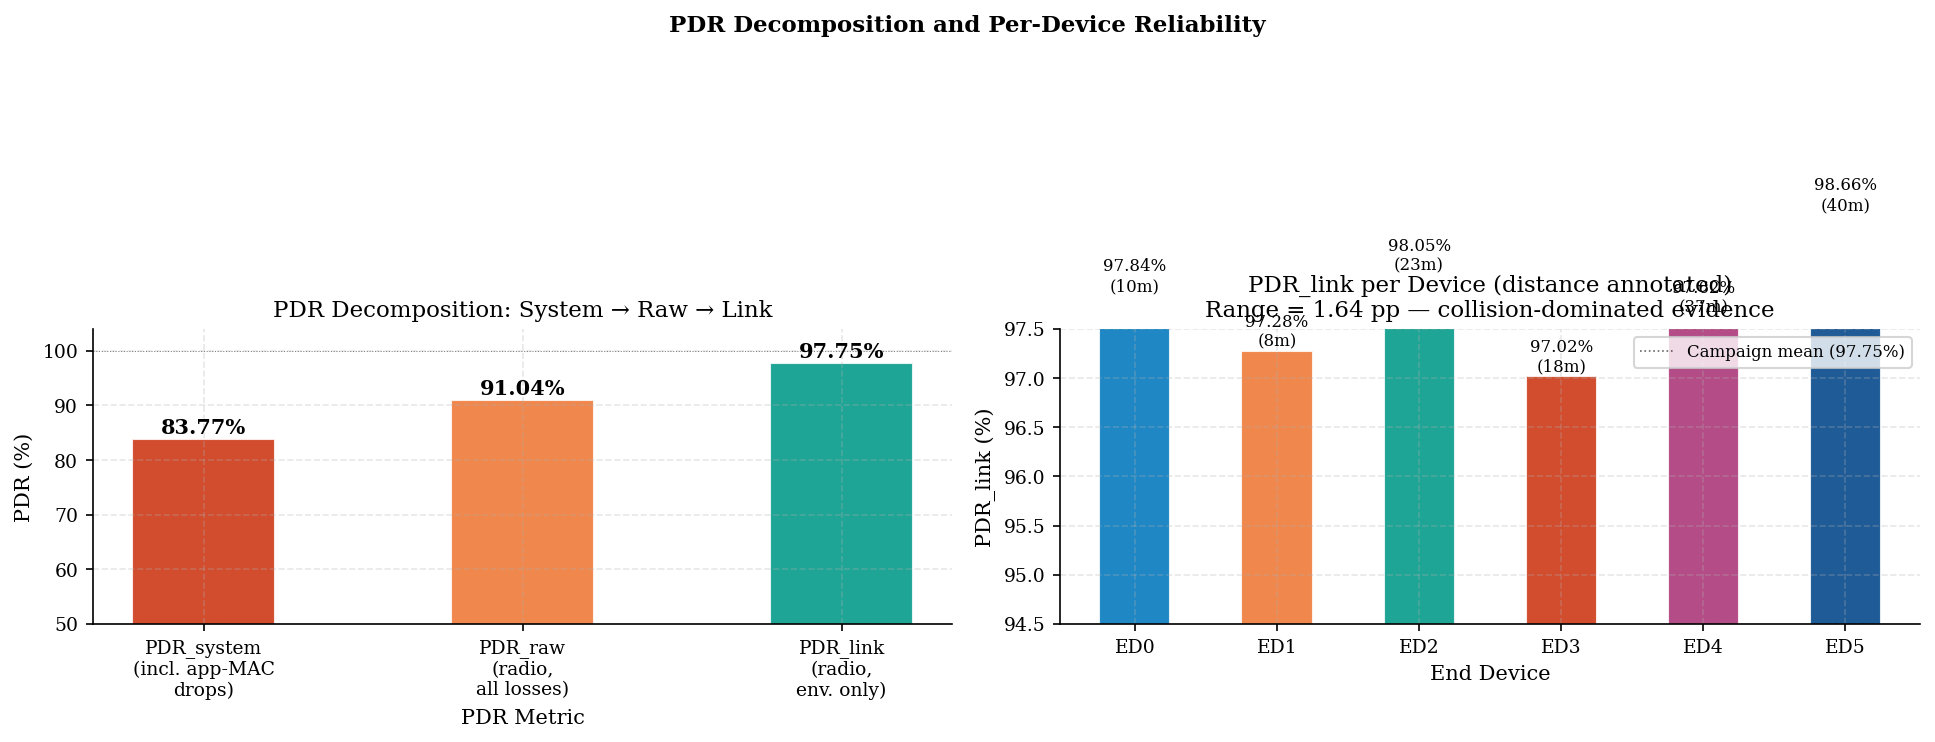

In [48]:
    # Fig 01_c — PDR Decomposition + Per-Device PDR_link
rx_all       = len(df)
lost_system  = int(df['total_loss'].sum())
lost_raw     = int(df['mac_to_radio_loss'].sum())
df_link_tmp  = df[~df['is_outage'] & ~df['is_sf_artifact']]
lost_link    = int(df_link_tmp['mac_to_radio_loss'].sum())
pdr_system_v = rx_all/(rx_all+lost_system)*100
pdr_raw_v    = rx_all/(rx_all+lost_raw)*100
pdr_link_v   = len(df_link_tmp)/(len(df_link_tmp)+lost_link)*100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: vertical bars — PDR_system, PDR_raw, PDR_link
categories = ['PDR_system\n(incl. app-MAC\ndrops)', 'PDR_raw\n(radio,\nall losses)', 'PDR_link\n(radio,\nenv. only)']
values_v   = [pdr_system_v, pdr_raw_v, pdr_link_v]
colors_v   = [C['red'], C['orange'], C['green']]
bars = axes[0].bar(categories, values_v, color=colors_v, width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, values_v):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(50, 104)
axes[0].set_ylabel('PDR (%)')
axes[0].set_xlabel('PDR Metric')
axes[0].axhline(y=100, color='grey', lw=0.5, ls=':')
axes[0].set_title('PDR Decomposition: System → Raw → Link')

# right: PDR_link per device with distance annotated
DEVICES_P = sorted(df['device_id'].unique())
dev_pdrs, dev_dists = [], []
for dev in DEVICES_P:
    g   = df_link_tmp[df_link_tmp['device_id']==dev]
    rx  = len(g); lost = int(g['mac_to_radio_loss'].sum())
    dev_pdrs.append(rx/(rx+lost)*100)
    dev_dists.append(int(df[df['device_id']==dev]['distance'].iloc[0]))

bars2 = axes[1].bar(DEVICES_P, dev_pdrs,
                     color=DEVICE_COLORS[:len(DEVICES_P)], width=0.5, alpha=0.88, edgecolor='white')
for bar, v, d in zip(bars2, dev_pdrs, dev_dists):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.2f}%\n({d}m)', ha='center', va='bottom', fontsize=8)
axes[1].axhline(y=pdr_link_v, color='black', lw=0.8, ls=':', alpha=0.6,
                label=f'Campaign mean ({pdr_link_v:.2f}%)')
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_xlabel('End Device')
axes[1].set_ylim(94.5, 97.5)
axes[1].set_title(f'PDR_link per Device (distance annotated)\nRange = {max(dev_pdrs)-min(dev_pdrs):.2f} pp — collision-dominated evidence')
axes[1].legend(fontsize=8)

fig.suptitle('PDR Decomposition and Per-Device Reliability', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_d_pdr_decomposition_per_device')

## 9 · Loss Decomposition Table  *(Table 7.1, §7.1)*

Full per-device breakdown of all loss components.  
`Total Lost = App-MAC + MAC-Radio` where `MAC-Radio = Artifact + Outage + Link Loss`.  
**`PDR_link` is the event-conditioned analysis metric — copy these values to Table 7.1.**

In [49]:
print(f"{'Dev':<6} {'Dist':^6} {'CW':^4} {'WW':^4} "
      f"{'Received':^10} {'Total Lost':^11} {'App-MAC':^9} {'MAC-Radio':^11} "
      f"{'Artifact':^10} {'Outage':^9} {'Link Loss':^11} "
      f"{'PDR_system':^11} {'PDR_link':^10} {'Resets':^7}")
print('-' * 145)

totals = {k: 0 for k in ['rx', 'app_mac', 'artifact', 'outage', 'link']}

for dev, g in df.groupby('device_id'):
    rx = len(g)
    app_mac = int(g['app_to_mac_drop'].sum())
    artifact = int(g[g['is_sf_artifact']]['mac_to_radio_loss'].sum())
    outage = int(g[g['is_outage']]['mac_to_radio_loss'].sum())
    g_link = g[~g['is_outage'] & ~g['is_sf_artifact']]
    link = int(g_link['mac_to_radio_loss'].sum())
    mac_radio = artifact + outage + link
    total_lost = app_mac + mac_radio

    for k, v in [('rx', rx), ('app_mac', app_mac), ('artifact', artifact), ('outage', outage), ('link', link)]:
        totals[k] += v

    pdr_system = rx / (rx + total_lost) * 100
    pdr_link = len(g_link) / (len(g_link) + link) * 100
    dist = int(g['distance'].iloc[0])
    cw   = int(g['c_walls'].iloc[0])
    ww   = int(g['w_walls'].iloc[0])
    rst  = int(g['is_reset'].sum())

    print(f"{dev:<6} {dist:^6} {cw:^4} {ww:^4} "
          f"{rx:^10,} {total_lost:^11,} {app_mac:^9,} {mac_radio:^11,} "
          f"{artifact:^10,} {outage:^9,} {link:^11,} "
          f"{pdr_system:^11.2f} {pdr_link:^10.2f} {rst:^7}")

print('-' * 145)
t = totals
mac_r = t['artifact'] + t['outage'] + t['link']
total = t['app_mac'] + mac_r
print(f"{'Total':<6} {'':^6} {'':^4} {'':^4} "
      f"{t['rx']:^10,} {total:^11,} {t['app_mac']:^9,} {mac_r:^11,} "
      f"{t['artifact']:^10,} {t['outage']:^9,} {t['link']:^11,} "
      f"{t['rx'] / (t['rx'] + total) * 100:^11.2f} {t['rx'] / (t['rx'] + t['link']) * 100:^10.2f}")

Dev     Dist   CW   WW   Received  Total Lost   App-MAC   MAC-Radio   Artifact   Outage    Link Loss  PDR_system   PDR_link  Resets 
-------------------------------------------------------------------------------------------------------------------------------------------------
ED0      10    0    0    440,166     82,310     39,670     42,640       751      32,182      9,707       84.25      97.84       8   
ED1      8     1    0    434,548     90,240     44,862     45,378       760      32,469     12,149       82.80      97.28       3   
ED2      23    0    2    440,920     83,905     42,083     41,822       719      32,337      8,766       84.01      98.05       3   
ED3      18    1    2    433,579     90,165     43,688     46,477       870      32,321     13,286       82.78      97.02       6   
ED4      37    0    5    435,416     89,358     45,534     43,824       868      32,377     10,579       82.97      97.62       2   
ED5      40    2    2    450,301     74,636     35,533  

## 10 · Column Order & Save

Columns reordered logically — originals first, derived last.

| Group | Columns |
|-------|---------|
| Identifiers | `device_id`, `time` |
| Environmental | `co2`, `humidity`, `pm25`, `pressure`, `temperature` |
| Radio metrics | `rssi`, `snr`, `esp`, `SF`, `frequency`, `toa` |
| Spatial | `distance`, `c_walls`, `w_walls`, `exp_pl`, `n_power` |
| Raw counters | `f_count`, `p_count` |
| Derived | all new columns from this notebook |

In [50]:
original_cols = [
    'device_id', 'time',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature',
    'rssi', 'snr', 'esp', 'SF', 'frequency', 'toa',
    'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power',
    'f_count', 'p_count',
]
derived_cols = [
    'mac_to_radio_loss',  # primary — radio losses
    'app_to_mac_drop',  # future work — app-to-MAC drops
    'total_loss',  # cross-validation — p_count equivalent
    'total_tx',  # TX attempts per interval
    'is_reset',  # device reboot flag
    'is_outage',  # infrastructure outage flag
    'is_sf_artifact',  # SF rotation artifact flag
    'loss_zone',  # zone classification
]

final_cols = [c for c in original_cols if c in df.columns] + derived_cols
df = df[final_cols]

df.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Rows  : {len(df):,}')
print(f'Cols  : {len(df.columns)}')

Saved : ..\data\1_reconstructed.csv
Rows  : 2,634,930
Cols  : 28
